In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.append('/home/future_commodity')
import os
import re
from pathlib import Path
from typing import List, Tuple

import numpy as np
np.seterr(all='ignore')
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from joblib import Parallel, delayed

import function_future.pre_train as pt
import function_future.train_model as tm
import function_future.FactorFilter as FF
import function_future.backtest_v3 as bv
import function_future.DataLoader as DL
import function_future.date_selection as DS
import function_future.trading_visualization as TV
from function_future.margin_calculator import calculate_margin, get_instrument_info, get_first_trade_date, get_recent_activity

In [3]:
symbol_lst = ["RB", "I", "SM", "SF", "HC", "SS", "J", "JM", "WR"] 

In [4]:
def bar_count(time_lst):
    if time_lst == ['09:00-11:30', '13:30-15:00', '21:00-23:00']:
        return 345
    if time_lst == ['09:00-11:30', '13:30-15:00']:
        return 225
    if time_lst == ['09:00-11:30', '13:30-15:00', '21:00-01:00']:
        return 465
    print("......wrong......")

In [5]:
init_money_lst = []
bar_dict = {}

for symbol in symbol_lst:
    margin = calculate_margin(symbol, 10)
    info = get_instrument_info(symbol)
    first_date = get_first_trade_date(symbol)
    activity = get_recent_activity(symbol)
    print(f"\n品种: {symbol} ({info.get('name', 'N/A')})")
    print(f"  品种交易时间： {info["trading_hours"]}")
    print(f"  首个交易日: {first_date}")
    # print(f"  95分位数价格: {info['price_95th']:.2f}")
    # print(f"  合约乘数: {info['contract_multiplier']}")
    # print(f"  保证金率: {info['margin_rate']:.2%}")
    # print(f"  10手保证金: {margin:,.2f}")
    print(f"  40%保证金所需本金: {margin / 0.4:,.0f} ")
    # print(f"  交易所: {info['exchange']}")
    print(f"  分均持仓量: {activity['avg_open_interest']:,.0f}")
    # print(f"  分均成交量: {activity['avg_volume']:,.0f}")
    # print(f"  分均成交额: {activity['avg_turnover']:,.0f}")
    bar_dict[symbol] = bar_count(info["trading_hours"])

    init_money_lst.append(int(margin / 0.4))


品种: RB (螺纹钢)
  品种交易时间： ['09:00-11:30', '13:30-15:00', '21:00-23:00']
  首个交易日: 2021-02-08
  40%保证金所需本金: 56,665 
  分均持仓量: 1,866,543

品种: I (铁矿石)
  品种交易时间： ['09:00-11:30', '13:30-15:00', '21:00-23:00']
  首个交易日: 2021-02-02
  40%保证金所需本金: 222,475 
  分均持仓量: 553,491

品种: SM (锰硅)
  品种交易时间： ['09:00-11:30', '13:30-15:00']
  首个交易日: 2021-02-01
  40%保证金所需本金: 69,210 
  分均持仓量: 355,431

品种: SF (硅铁)
  品种交易时间： ['09:00-11:30', '13:30-15:00']
  首个交易日: 2021-02-01
  40%保证金所需本金: 60,160 
  分均持仓量: 201,995

品种: HC (热轧卷板)
  品种交易时间： ['09:00-11:30', '13:30-15:00', '21:00-23:00']
  首个交易日: 2021-02-08
  40%保证金所需本金: 60,043 
  分均持仓量: 1,347,076

品种: SS (不锈钢)
  品种交易时间： ['09:00-11:30', '13:30-15:00', '21:00-01:00']
  首个交易日: 2021-02-08
  40%保证金所需本金: 124,994 
  分均持仓量: 124,247

品种: J (焦炭)
  品种交易时间： ['09:00-11:30', '13:30-15:00', '21:00-23:00']
  首个交易日: 2021-02-02
  40%保证金所需本金: 881,500 
  分均持仓量: 40,197

品种: JM (焦煤)
  品种交易时间： ['09:00-11:30', '13:30-15:00', '21:00-23:00']
  首个交易日: 2021-02-02
  40%保证金所需本金: 225,810 
  分均持仓量: 525,

In [6]:
initial_capital = dict(zip(symbol_lst, init_money_lst))
initial_capital

{'RB': 56665,
 'I': 222475,
 'SM': 69210,
 'SF': 60160,
 'HC': 60042,
 'SS': 124993,
 'J': 881500,
 'JM': 225810,
 'WR': 87550}

In [7]:
weights = dict(zip(symbol_lst, [5_000_000 // x for x in init_money_lst]))
weights

{'RB': 88,
 'I': 22,
 'SM': 72,
 'SF': 83,
 'HC': 83,
 'SS': 40,
 'J': 5,
 'JM': 22,
 'WR': 57}

In [8]:
train_label = 5
rtn_mul = 1

bt_params = (0.9, 0.5, 10, 5)
train_end_date = '2025-01-01'

In [9]:
file_name = '_'.join(symbol_lst)

In [10]:
def run_res(symbol, bt_params):
    folder_name = f'{symbol}_pred{train_label}_{train_end_date}_v0'

    config_loader = DL.InstrumentConfig()
    config_loader.get_instrument_config(symbol)

    config = bv.load_config(r"/mnt/Data/writable/liaoyuyang/backtest/backtest_config.json")
    config['MODEL_DIR'] = f'/home/strategy_res/multi_train/models/{file_name}@700'

    bt = bv.ModelBacktester(train_end_date, config)
    bt.load_config(symbol)
    bt.window_end = '2027-01-01'
    bt.money = initial_capital[symbol]
    bt.fee = 0

    # bt.load_factor(symbol, end_date=bt.window_end)

    factor_single = pd.read_feather(f'/home/strategy_res/multi_train/merged_df/{file_name}.feather')
    factor_single = factor_single[factor_single['symbol'] == symbol].reset_index(drop=True)
    factor_single['hour'] = factor_single.datetime.dt.hour
    factor_single = factor_single[factor_single.datetime >= train_end_date]
    # factor_single = factor_single[factor_single.datetime.astype('datetime64[ns]').between(start_date, end_date)]
    
    factor_single = factor_single.sort_values('datetime').drop_duplicates('datetime', keep='last')
    factor_single = factor_single[~((factor_single['datetime'].dt.hour == 10) & (factor_single['datetime'].dt.minute == 30))]
    factor_single['datetime'] = pd.to_datetime(factor_single.datetime)
    bt.factor_single = factor_single.round(8) 

    bt.load_mktdata(symbol, end_date=bt.window_end)
    bt.load_models()
    bt.generate_predictions()
    pred = bt.combine_models('best_iteration_log_weighted', avg=True)

    th1, th2, holding_bars, day = bt_params
    day = day * bar_dict[symbol]
   

    merged_data = bt.backtest(th1=th1, th2=th2, save=False, open_drop=True, holding_bars=holding_bars,
                           day=day, model_name='best_iteration_log_weighted', v=2
                        )

    return merged_data

In [11]:
merged_data_lst = []
for symbol in symbol_lst:
    print(f"\nProcessing {symbol}...")
    merged_data = run_res(symbol, bt_params)
    merged_data_lst.append(merged_data)


Processing RB...
trading_hours ['09:00-11:30', '13:30-15:00', '21:00-23:00']
使用的交易价格 tick6t60avg


计算持仓表:   0%|          | 0/84381 [00:00<?, ?it/s]


Processing I...
trading_hours ['09:00-11:30', '13:30-15:00', '21:00-23:00']
使用的交易价格 tick6t60avg


计算持仓表:   0%|          | 0/84903 [00:00<?, ?it/s]


Processing SM...
trading_hours ['09:00-11:30', '13:30-15:00']


...

  0%|          | 0/84903 [00:00<?, ?it/s]


Processing JM...
trading_hours ['09:00-11:30', '13:30-15:00', '21:00-23:00']


  0%|          | 0/84903 [00:00<?, ?it/s]


Processing WR...
trading_hours ['09:00-11:30', '13:30-15:00']


  0%|          | 0/44867 [00:00<?, ?it/s]

In [12]:
def plot_all(symbol_lst, merged_data_lst, weights=None):
    pnl_ret = []
    for i, merged_data in enumerate(merged_data_lst):
        symbol = symbol_lst[i]
        df = merged_data.set_index('datetime')[['equity', 'date']]
        df.rename(columns={'equity':symbol}, inplace=True)
        df = df.groupby('date').last()
        # 如果有权重配置，应用权重
        if weights and symbol in weights:
            df[symbol] = df[symbol] * weights[symbol]

        # df = df.iloc[:-30]

        pnl_ret.append(df)

    return pd.concat(pnl_ret,axis=1).ffill().iloc[:-30]

In [13]:
merged_df_all = plot_all(symbol_lst, merged_data_lst, weights=weights).drop(columns=["WR"])
merged_df_all

,RB,I,SM,SF,HC,SS,J,JM
date,,,,,,,,
2025-01-02,5.084824e+06,4.860245e+06,4.951827e+06,4.943422e+06,4.993137e+06,4.999019e+06,4.453335e+06,5.067775e+06
2025-01-03,5.087566e+06,4.738809e+06,5.057363e+06,4.712286e+06,5.209880e+06,4.896357e+06,4.613629e+06,4.983349e+06
2025-01-06,5.079527e+06,5.012713e+06,5.054779e+06,4.682895e+06,5.346119e+06,4.791802e+06,4.587949e+06,4.722386e+06
2025-01-07,5.114215e+06,4.998854e+06,5.046280e+06,4.710348e+06,5.539490e+06,4.934050e+06,4.655906e+06,4.964618e+06
2025-01-08,5.191037e+06,5.177752e+06,4.963845e+06,4.663878e+06,5.470846e+06,5.154704e+06,4.687056e+06,5.236537e+06
...,...,...,...,...,...,...,...,...
2026-01-13,1.337115e+07,1.630701e+07,6.165551e+06,-2.322907e+06,1.270540e+07,1.021101e+07,1.081891e+07,1.829472e+07
2026-01-14,1.340150e+07,1.636219e+07,6.096450e+06,-2.316637e+06,1.282971e+07,1.037072e+07,1.078782e+07,1.833464e+07
2026-01-15,1.343799e+07,1.634832e+07,6.175753e+06,-2.223859e+06,1.288981e+07,9.807453e+06,1.087415e+07,1.852697e+07


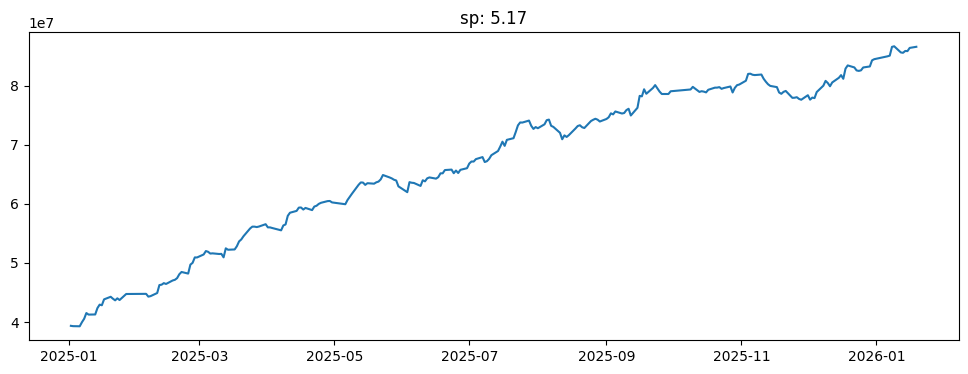

In [14]:
sp = merged_df_all.sum(axis=1).diff().mean() / merged_df_all.sum(axis=1).diff().std() * np.sqrt(252)
plt.figure(figsize=(12, 4))  # Correct way to set figure size
plt.plot(merged_df_all.sum(axis=1))
plt.title(f'sp: {round(sp,2)}')
plt.show()

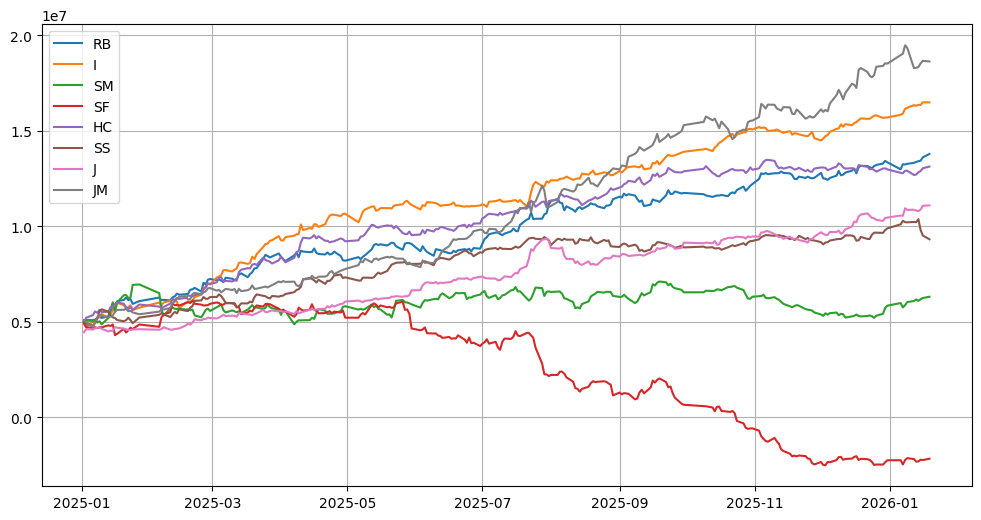

In [15]:
fig = plt.figure(figsize=(12, 6))
plt.plot(merged_df_all)
plt.legend(symbol_lst)
plt.grid()
plt.show()

In [16]:
res = pd.concat((bv.analyze_pos_distribution(merged_data_lst[i]) for i in range(len(symbol_lst))), axis=1)
res.columns = symbol_lst
res

,RB,I,SM,SF,HC,SS,J,JM,WR
多头(+1) 数量,18379,17734,12160,11936,18265,25826,16901,16756,9083
空头(-1) 数量,18421,17864,12190,13018,19184,26759,19367,18625,8696
空仓(0) 数量,47583,49307,33178,32574,46934,64595,48637,49524,27090
多头占比,21.78%,20.89%,21.14%,20.75%,21.65%,22.04%,19.91%,19.73%,20.24%
空头占比,21.83%,21.04%,21.19%,22.63%,22.73%,22.84%,22.81%,21.94%,19.38%
空仓占比,56.39%,58.07%,57.67%,56.62%,55.62%,55.12%,57.28%,58.33%,60.38%
交易日数量,283,284,282,282,283,283,284,284,281
总收益(非年化%),185.91,238.43,43.68,-140.82,178.03,108.62,151.27,241.38,611.25
总交易次数（开平算一次）,3630,3940,2846,2480,4006,5140,3622,3559,1763
日均交易次数（开平算一次）,12.83,13.87,10.09,8.80,14.15,18.16,12.75,12.53,6.27
